# STATISTICS AND PROBAB

So we'll we working with the cleaned titanic dataset available on my github so lets start by importing the required library and dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
cleaned=r"C:\Users\ADMIN\OneDrive\Documents\Analyst Lab africa deliverables\Cleaned Titanic Dataset.csv"
titanic=pd.read_csv(cleaned)
titanic

,Unnamed: 0,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,0,3,0,22.0,1,0,7.2500,0.0
1,1,1,1,1,38.0,1,0,71.2833,1.0
2,2,1,3,1,26.0,0,0,7.9250,0.0
3,3,1,1,1,35.0,1,0,53.1000,0.0
4,4,0,3,0,35.0,0,0,8.0500,0.0
...,...,...,...,...,...,...,...,...,...
886,886,0,2,0,27.0,0,0,13.0000,0.0
887,887,1,1,1,19.0,0,0,30.0000,0.0
888,888,0,3,1,28.0,1,2,23.4500,0.0
889,889,1,1,0,26.0,0,0,30.0000,1.0


# DESCRIPTIVE STATISTICS

Lets get a descriptive summary of our dataset

In [5]:
titanic.describe()

,Unnamed: 0,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,889.000000
mean,445.000000,0.383838,2.308642,0.352413,29.361582,0.523008,0.381594,32.204208,0.362205
std,257.353842,0.486592,0.836071,0.477990,13.019697,1.102743,0.806057,49.693429,0.636157
min,0.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,222.500000,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,0.000000
50%,445.000000,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,667.500000,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,1.000000
max,890.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000


So theres an unamed index that should be removed lets drop that 

In [8]:
titanic.drop(columns=['Unnamed: 0'],inplace=True)
titanic

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0.0
1,1,1,1,38.0,1,0,71.2833,1.0
2,1,3,1,26.0,0,0,7.9250,0.0
3,1,1,1,35.0,1,0,53.1000,0.0
4,0,3,0,35.0,0,0,8.0500,0.0
...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,0.0
887,1,1,1,19.0,0,0,30.0000,0.0
888,0,3,1,28.0,1,2,23.4500,0.0
889,1,1,0,26.0,0,0,30.0000,1.0


In [9]:
titanic.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,889.000000
mean,0.383838,2.308642,0.352413,29.361582,0.523008,0.381594,32.204208,0.362205
std,0.486592,0.836071,0.477990,13.019697,1.102743,0.806057,49.693429,0.636157
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,0.000000
50%,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,1.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000


Now we can see a brief descriptive statistics of our dataset from the mean to standard deviation and more

# PROBABILITY DISTRIBUTION
lets perform some probability distribution function and cumulative distribution function


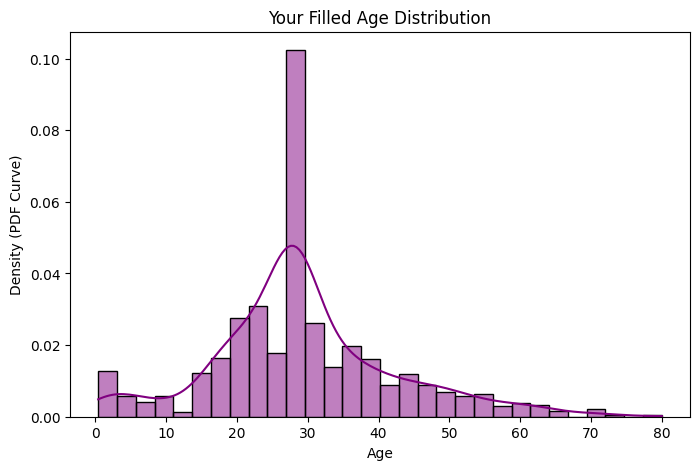

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(titanic['Age'], kde=True, color='purple',stat='density')
plt.title('Your Filled Age Distribution')
plt.xlabel('Age')
plt.ylabel('Density (PDF Curve)')
plt.show()


From this we can see the likelyhood of a new passenger age, most passengers in the ship are of age 20-30 the probability of picking a 29 is very high. So lets check for the probability of picking range 0-19 

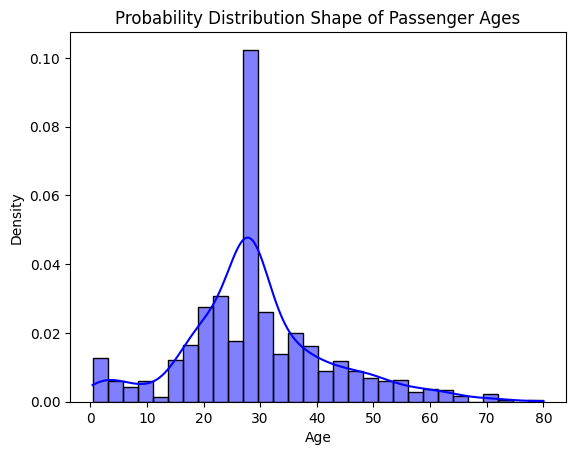

Mathematical probability of picking a child under 18: 0.1914 (19.1%)


In [12]:
import scipy.stats as stats

# Plotting the Probability Density (KDE Curve) over the dataset
sns.histplot(titanic['Age'], kde=True, stat="density", color="blue")
plt.title("Probability Distribution Shape of Passenger Ages")
plt.show()

# Calculate the exact mathematical probability of a passenger being a child (<= 18)
mean_age = titanic['Age'].mean()
std_age = titanic['Age'].std()

prob_child = stats.norm.cdf(18, loc=mean_age, scale=std_age)
print(f"Mathematical probability of picking a child under 18: {prob_child:.4f} ({prob_child*100:.1f}%)")


# HYPOTHESIS TESTING
Lets check for hypothesis by check how fare affects the rate of survival i mean the fare that the survived paid and the fare that the perished paid do they differ?

In [16]:
survived_fares = titanic[titanic['Survived'] == 1]['Fare']
perished_fares = titanic[titanic['Survived'] == 0]['Fare']

# Run the T-Test 
t_stat, p_value = stats.ttest_ind(survived_fares, perished_fares, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value}")

T-Statistic: 6.8391
P-Value: 2.6993323503141236e-11


From this hypothesis testing we can see that the pvalue equates to 0.000000000026 which is close to 0% so we can deduce that the ticlet price really mattered a lot  

# CORELLATION VS CAUSATION
Lets bulid a correlation matrix for our variables

In [22]:
correlation_matrix = titanic[['Survived', 'Pclass', 'Fare', 'Age', 'SibSp', 'Parch']].corr()
print(correlation_matrix)


          Survived    Pclass      Fare       Age     SibSp     Parch
Survived  1.000000 -0.338481  0.257307 -0.064910 -0.035322  0.081629
Pclass   -0.338481  1.000000 -0.549500 -0.339898  0.083081  0.018443
Fare      0.257307 -0.549500  1.000000  0.096688  0.159651  0.216225
Age      -0.064910 -0.339898  0.096688  1.000000 -0.233296 -0.172482
SibSp    -0.035322  0.083081  0.159651 -0.233296  1.000000  0.414838
Parch     0.081629  0.018443  0.216225 -0.172482  0.414838  1.000000
